# KSP Mission Planning: Mun Robotic Mission (ESTACA 5A)

**Reference:** KSC - https://www.kerbalspacechallenge.fr/fr/ksc-fr/

## 0. The misssion

A space vehicle composed of a command module and a 2 stage lander is on a
Mun flyby trajectory, from this initial point, you must :
- Capture the vehicle in Mun orbit
- Separate the lander
- Land and the Mun less than 5km from the target {26°40’44”N 33°5’31”E}
- Return to Mun orbit and rendez vous with the command module
- Bring the command module back to Kerbin surface, land less than 60km from
the recovery area {4°N ; 68°30’W}

**Constraints:**

- Stay at least 30 minutes on the surface to perform science
- Insure a safe moon landing in daylight without risk of sun dazzle
- Sun elevation = 30°
- Sun relative azimut < 90
- Minimize the number of critical maneuvers
- Have a free return trajectory
- Minimize cost and DeltaV
- Minimize the duration of the mission
- Return with only one atmospheric entry

![Objectives](images/Objectives.png)

![initial conditions](images/initial_conditions.png)


## 1. Setup and Constants

Defining celestial body parameters (PDF Page 14) and Physics constants.

In [1]:
import numpy as np
import math

# --- Constants (PDF Page 13-14) ---
G = 6.67430e-11
g0 = 9.80665  # Standard gravity for ISP conversion

class Body:
    def __init__(self, name, mu, radius, rotation_period, a):
        self.name = name
        self.mu = mu              # Gravitational parameter (m^3/s^2)
        self.radius = radius      # Equatorial radius (m)
        self.rot_period = rotation_period # Sideral rotation period (s)
        self.a = a # Semi-major axis (m)

# Data from PDF Page 14
kerbin = Body("Kerbin", 3.5316e12, 600000, 21549.425, 13599840256)  
mun = Body("Mun", 6.5138e10, 200000, 138984.377, 12000000)



## 2. Phase 1: Mun Capture & Orbit
**Goal:** Capture into a circular orbit        


![formula](images/formuleCircularisation.png)

In [2]:

# --- Inputs ---
altitude_pe = 25796 # m (Mun Periapsis Altitude from current flyby, take from map view)
v_inf =  505.7 # m/s (From Mun encounter data in map view)

# --- Calculation ---
r_pe = mun.radius + altitude_pe


v_inf =  505.7 # m/s
rsoi= mun.a * ((mun.mu) / (kerbin.mu))**(2/5)  # Approximate SOI radius at encounter  

dv_circularize = np.sqrt(v_inf**2 + 2*mun.mu/r_pe - 2*mun.mu/rsoi) - np.sqrt(mun.mu/r_pe)

print(f"Circularization Delta V: {dv_circularize:.2f} m/s")


Circularization Delta V: 345.55 m/s


![formula](images/firstMan.png)


## 3. Phase 2: Landing Window & Powered Descent
**Constraints:** 
* Sun Elevation = $30^\circ$ (PDF p. 41-43), SRA < $90^\circ$         
* Minimize $\Delta V$ using Suicide Burn (Inverse Gravity Turn, PDF p. 70-77).                   



### 3a. Lighting Condition    
 

In [3]:
def dms_to_dec(deg, min, sec, direction):
    """Converts Degrees Minutes Seconds to Decimal Degrees."""
    sign = 1 if direction in ['N', 'E'] else -1
    return sign * (deg + min/60 + sec/3600)

kerbin_year_duration = 426 * 6 * 3600 # 9190800 s
def ut_to_dh_str(ut):
    """Converts UT to string 'dJ hH'"""
    rem = ut % kerbin_year_duration
    d = int(rem // (6*3600)) + 1
    rem %= (6*3600)
    h = int(rem // 3600)
    rem %= 3600
    m = int(rem // 60)
    s = int(rem % 60)
    return f"d{d} h{h} m{m} s{s}"  

def date_to_sec(y, d, h, m, s):
    """Converts a date to UT seconds."""
    total_seconds = (y - 1) * kerbin_year_duration
    total_seconds += (d - 1) * 6 * 3600
    total_seconds += h * 3600
    total_seconds += m * 60
    total_seconds += s
    return total_seconds

In [4]:
# --- Inputs ---
target_lat_dms = (26, 40, 44, 'N')
target_lon_dms = (33, 5, 31, 'E')
target_lat = dms_to_dec(*target_lat_dms)
target_lon = dms_to_dec(*target_lon_dms)
print(f"Target Latitude: {target_lat:.4f}°")
print(f"Target Longitude: {target_lon:.4f}°")
current_date = {'y': 1, 'd': 7, 'h': 5, 'm': 0, 's': 0}

Target Latitude: 26.6789°
Target Longitude: 33.0919°


This graph is a decision-support tool for the landing phase. It combines two crucial pieces of information to validate safety constraints:

* Solar Elevation (Orange Curve): It must be approximately 30° at landing time to ensure good terrain visibility without overly long shadows or sun at zenith. The red dashed line indicates this target.

* Relative Azimuth (Colored Zones): The SRA<90° constraint requires landing with the sun "behind" or to the side, not in front, to avoid sun dazzle. For a classic retrograde approach (westward), this corresponds to Morning (Sun in the East).

* Green Zone: Lunar morning. The sun is in the East. This is the safe firing window.

* Red Zone: Afternoon/Evening lunar. The sun is in the West (facing the descent). Risk of glare.

Reading: The red points marked "Optimal" identify the exact dates when elevation crosses 30° while being in the green zone, thus satisfying all lighting constraints.

--- Firing Windows (30° Elevation + Morning) ---
OPTIMAL OPPORTUNITY: d8 h1 m35 s22 (T + 2.6h)
OPTIMAL OPPORTUNITY: d14 h4 m47 s17 (T + 41.8h)
OPTIMAL OPPORTUNITY: d21 h1 m59 s12 (T + 81.0h)


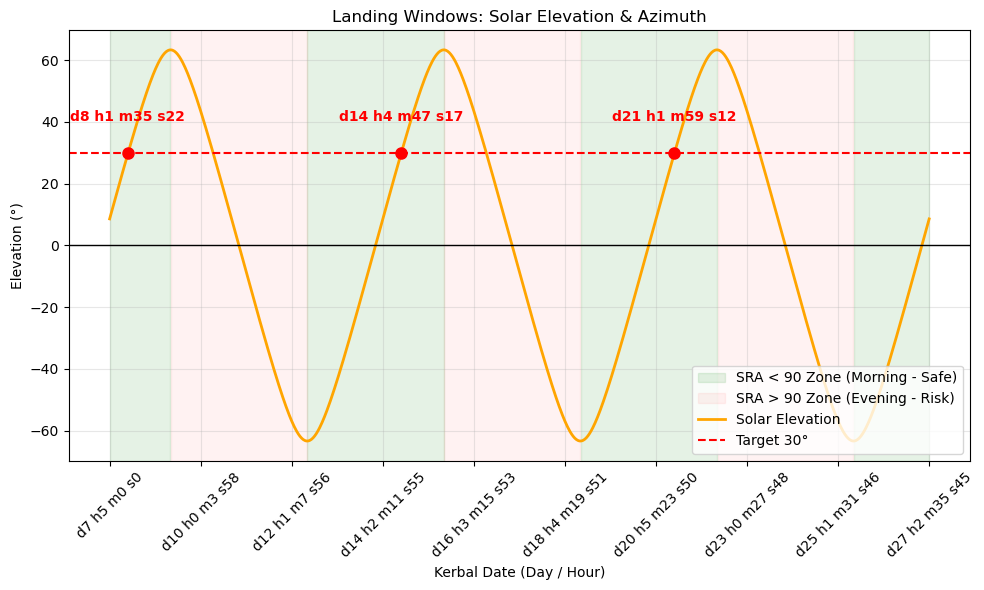

In [5]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import math

# --- 1. Parameters & Constants ---
# KSP Constants (Source PDF)
kerbin_year_duration = 426 * 6 * 3600 # 9190800 s
mun_rotation_period = 138984.377      # T_sid Mun

# Initial Conditions at t=0 (Source: Table Page 14)
LSID0_MUN_DEG = 230.0  # Initial sidereal rotation of the Mun

# Site Coordinates (Target)
lat_rad = np.radians(target_lat)


# --- 2. Complete Astronomical Functions ---

def calculate_sun_coords_corrected(ut):
    """
    Calculates elevation AND azimuth (SRA) using Lsid0 = 230°.
    """
    # A. Sun Position (Inertial)
    n_kerbin = 2 * np.pi / kerbin_year_duration
    theta_sun_inertial = 0 + n_kerbin * ut 
    
    # B. Site Position (Inertial)
    n_mun_rot = 2 * np.pi / mun_rotation_period
    theta_meridian_inertial = np.radians(LSID0_MUN_DEG) + n_mun_rot * ut
    theta_site_inertial = theta_meridian_inertial + np.radians(target_lon)
    
    # C. Local Hour Angle (h)
    h = theta_site_inertial - theta_sun_inertial
    h = (h + np.pi) % (2 * np.pi) - np.pi # Normalization (-pi, pi)
    
    # D. Horizontal Coordinates (delta=0)
    phi = lat_rad
    
    # Elevation (alpha_s)
    sin_alpha = np.cos(phi) * np.cos(h)
    alpha_s = np.arcsin(sin_alpha)
    
    # Azimuth (SRA) - KSP Approximation
    # On the Mun (without tilt), the relative azimuth to the sun depends on the sign of h.
    # h < 0 (Morning) => Sun in East => Azimuth ~90° => SRA < 90° (Back to sun if West approach)
    # h > 0 (Evening) => Sun in West => Azimuth ~270° => SRA > 90° (Facing sun)
    # Rigorous azimuth calculation (0=North, 90=East)
    cos_alpha = np.cos(alpha_s)
    if cos_alpha < 1e-6:
        azimuth_deg = 0
    else:
        sin_az = -np.sin(h) / cos_alpha
        cos_az = (-np.sin(phi) * np.cos(h)) / cos_alpha
        azimuth_deg = np.degrees(np.arctan2(sin_az, cos_az)) % 360
        
    # SRA Calculation (Sun Relative Azimuth for retrograde/West approach)
    # If going West (heading 270), and Sun in East (90), SRA = 180 (Back) -> OK
    # The SRA < 90 constraint from PDF seems to indicate the opposite or a different reference frame.
    # Standard "Safe" interpretation: Morning (Sun East) = OK.
    is_morning = (0 < azimuth_deg < 180)

    return np.degrees(alpha_s), is_morning

# --- 3. Simulation ---
start_ut = (current_date['y']-1)*kerbin_year_duration + (current_date['d']-1)*6*3600 + current_date['h']*3600

duration = 3 * 141115 # 3 Mun days
time_array = np.linspace(start_ut, start_ut + duration, 1000)

elevations = []
is_safe_sra = [] # Boolean for green zone
hours_relative = []
date_labels = [] 

for t in time_array:
    el, safe = calculate_sun_coords_corrected(t)
    elevations.append(el)
    is_safe_sra.append(safe)
    hours_relative.append((t - start_ut) / 3600)
    date_labels.append(ut_to_dh_str(t))

# --- 4. Display ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# SRA Zones (Morning vs Evening)
# Fill background in green when it's morning (Safe)
# Using transform=ax1.get_xaxis_transform() to cover full height (y=0 to 1 in axes coordinates)
ax1.fill_between(hours_relative, 0, 1, where=is_safe_sra, 
                 color='green', alpha=0.1, transform=ax1.get_xaxis_transform(), label='SRA < 90 Zone (Morning - Safe)')
ax1.fill_between(hours_relative, 0, 1, where=[not x for x in is_safe_sra], 
                 color='red', alpha=0.05, transform=ax1.get_xaxis_transform(), label='SRA > 90 Zone (Evening - Risk)')

# Elevation Curve
ax1.plot(hours_relative, elevations, color='orange', linewidth=2, label='Solar Elevation')
ax1.axhline(30, color='red', linestyle='--', label='Target 30°')
ax1.axhline(0, color='black', linewidth=1)

ax1.set_ylabel('Elevation (°)')
ax1.set_title('Landing Windows: Solar Elevation & Azimuth')
ax1.grid(True, alpha=0.3)

# X-Axis Dates
num_ticks = 10
tick_indices = np.linspace(0, len(hours_relative)-1, num_ticks, dtype=int)
ax1.set_xticks([hours_relative[i] for i in tick_indices])
ax1.set_xticklabels([date_labels[i] for i in tick_indices], rotation=45)
ax1.set_xlabel('Kerbal Date (Day / Hour)')

# Window Detection (30° Rising Intersection)
print(f"--- Firing Windows (30° Elevation + Morning) ---")
for i in range(len(elevations) - 1):
    # Condition: Crossing 30° rising AND in Safe zone (Morning)
    if elevations[i] < 30 and elevations[i + 1] >= 30:
        if is_safe_sra[i]: # SRA Check
            t_h = hours_relative[i]
            date_str = date_labels[i]
            ax1.plot(t_h, 30, 'ro', markersize=8)
            ax1.annotate(f'{date_str}\n', (t_h, 35), color='red', fontweight='bold', ha='center')
            print(f"OPTIMAL OPPORTUNITY: {date_str} (T + {t_h:.1f}h)")

ax1.legend(loc='lower right')
plt.tight_layout()
plt.show()

Given the time for one orbit around the Mun at 26000m, we need to wait 2 orbits before landing on day 8 at approximately 1h.

### 3b. landing 

![landing](images/landing.png)

In [6]:
# Time between I and B is a half orbit.
r_B = 6000 + mun.radius # we target 6000m altitude for B
t_IB = np.pi * np.sqrt(((r_pe + r_B)/2)**3 / mun.mu) 

# Time between B and A is given by the formula 
TWR = 4.62 # thrust to weight ratio
v_init = 535.7 # m/s
g = mun.mu / r_B**2 # m/s²
t_BA = v_init/g * (TWR/(TWR**2 -1))

t_IA = t_IB + t_BA

# Ground distance between B and A is given by
v_B = np.sqrt(2*mun.mu/r_B - mun.mu/((r_pe + r_B)/2))
d_BA = (2 * v_B**2 / g) * (TWR/ (4*TWR**2 -1))

angle_BA = 2*np.pi * (d_BA / (2 * np.pi * mun.radius))
# Ground distance between I and B is half the Mun circumference
d_IB = np.pi * mun.radius

angle_total = angle_BA + np.pi
angle_total_rotation_corrected = angle_total + (2 * np.pi / mun_rotation_period) * t_IA # + because retrograde orbit

print("Phase angle:", angle_total_rotation_corrected * (180/np.pi))
print("Phase angle as displayed in KSP:", angle_total_rotation_corrected * (180/np.pi) - 360)

Phase angle: 190.16259465553924
Phase angle as displayed in KSP: -169.83740534446076


By setting the flag as target, KSP gives us the phase angle relative to the target, so the maneuver must be performed when the phase angle reaches -169.8° on the KSP display.

![169.8°](images/169_8.png)

In [7]:
print("To cancel orbital velocity, thrust retrograde at max \nstarting from a phase angle with target of:", angle_BA * (180/np.pi))

To cancel orbital velocity, thrust retrograde at max 
starting from a phase angle with target of: 6.7588418555918786


### 3c. Suicide Burn

In [8]:
# The final burn ignition altitude is given by the formula:
h0 = 2000 # altitude in meters of the point where the velocity has been cancelled.
new_TWR = 5.48
h_ignition = h0/new_TWR

print(f"Final burn ignition altitude: {h_ignition:.0f} m")

Final burn ignition altitude: 365 m


![landing](images/atterrissage.png)

As calculated, we arrive close to the target. Knowing we stay 30 min on the Mun and arrive on Day 8 at 0h 45min, we are exactly within the defined sunlight window.

## 4. Phase 3: Ascent & Rendezvous


### 3d. Result

Takeoff from A, circularization at B, Hohmann transfer at C, RDV at E

![RDV](images/shemaRDV.png)

To optimize the maneuver in time while using minimum propellant, point C should be close to point B, meaning point E should be close to point D (t_BC=0). We therefore need to calculate when the command module will be at point D (date_modD), add a small safety margin (t_margin), determine the time between C and E (t_CE), and estimate the time between A and B (t_AB).

Takeoff must occur at:
```python
date_take_off = date_modD - ( t_AB + t_BC + t_CE ) + t_margin
```
Here we take a positive margin because we will be faster than the module when on the green orbit, so this is where we can perfectly adjust the RDV timing and potentially wait longer for the perfect moment.

In [9]:
# Estimation (takeoff done manually in KSP):
t_AB = 60 * 3 # s
angle_AB = 5 # °, the module will be at point D when it has a phase angle with target of 180-5 => 175°
t_BC = 0 # Set to 0 as it's ideal but not realistic, so included in the margin
r_B = 14000 + mun.radius
t_margin = 90 # s
v_apoapsis_takeoff_traj = 100 # m/s
date_modD = {'y': 1, 'd': 8, 'h': 1, 'm': 50, 's': 46} # date where the module will be at the point D, it's estimated from KSP screenshot 
# below knowing that given the need to stay 30 min on the Mun, the module completed one full orbit while the lander was on the Mun.

![date_mod_D](images/date_modD.png)

In [10]:
t_CE = np.pi * np.sqrt(((r_B + r_pe)/2)**3 / (mun.mu)) # half orbit between C and E
print(f"Time C to E: {t_CE:.2f} seconds")

date_takeoff = ut_to_dh_str(date_to_sec(**date_modD) - t_AB - t_BC - t_CE + t_margin)

print(f"Takeoff will occur at: {date_takeoff}, aiming for an initial parabolic trajectory to reach an apoapsis at {r_B - mun.radius} m altitude. \nIt will align with the command module orbit inclination of 153°, targeting an angle of 5° between B and A.")

Time C to E: 1269.30 seconds
Takeoff will occur at: d8 h1 m28 s6, aiming for an initial parabolic trajectory to reach an apoapsis at 14000 m altitude. 
It will align with the command module orbit inclination of 153°, targeting an angle of 5° between B and A.


In [22]:
v_circularize = np.sqrt(mun.mu / r_B)

dv_circularize = v_circularize - v_apoapsis_takeoff_traj
print(f"Delta v for circularization: {dv_circularize:.2f} m/s")

v_B_transfer = np.sqrt(2*mun.mu/r_B - mun.mu/((r_pe + r_B)/2))
dv_transfer = v_circularize - v_B_transfer

print(f"Delta v for transfer: {dv_transfer:.2f} m/s")

Delta v for circularization: 451.71 m/s
Delta v for transfer: -7.35 m/s


**Given the approximations, actual maneuvers are slightly different but close.** 

circu: ![man_circu](images/manoeuvre_reel_circu.png)
<style>
/* Reduce image size for images containing "man" in their name (only affects this cell) */
img[src*="man"] {
    max-width: 700px;
    height: auto;
    display: inline-block;
    margin-right: 8px;
}
</style>
![man_rdv1](images/man_rdv2.png) ![man_rdv](images/man_reel_rdv.png)

**Final docking** exemple: https://docs.google.com/file/d/1_TjXe_jKSCjHynhfiBZBEeOF8Abp5oFN/preview

![docking](images/docking.png)

## 4. Phase 4: Return to Kerbin

**Objective:**
Land at **4° N ; 68° 30' W** with only **one atmospheric entry** and a **vacuum perigee of 35 km**.

To achieve this precision return, we must synchronize the departure from the Mun with the rotation of Kerbin so that the landing site aligns with the arrival trajectory. 

**Key Parameters & Constraints:**
- **Kerbin Rotation Period:** ~21,549 s
- **Mun Orbital Period:** ~138,984 s
- **Target Coordinates:** 4° N ; 68° 30' W
- **Trajectory Duration:** The return trip from the Mun's hidden face (departure point) to Kerbin's vacuum perigee (35 km) takes approximately **18,000 s**.
- **Atmospheric Shift:** After reaching the vacuum perigee at 35 km, the lander travels an additional **13.8°** longitude arc through the atmosphere before touching down. This shift is accounted for in the targeting.

**Trajectory Synchronization Strategy:**
We depart from the **hidden face of the Mun** (Point C) to target a periapsis at 35 km altitude on the **hidden face of Kerbin** (Point B). We track two positions over time:
- `pos_B(t)`: The longitude of the target landing site relative to the arrival point (adjusted for Kerbin's rotation during the 18,000s transit).
- `pos_C(t)`: The longitude of the Mun's hidden face (optimal departure point).

A valid launch window occurs when `pos_B(t) == pos_C(t)`.

### 4a. Mathematical Model for Synchronization

To find the correct departure window, we compare the inertial longitude of the target landing site at the moment of arrival against the inertial longitude of the departure point on the Mun's orbit.

**1. Position of the Target at Arrival (pos_B):**
This corresponds to the inertial longitude of the landing site at the moment the spacecraft reaches periapsis (after transit).
$$ \text{pos}_B(t) = \lambda_{target} - \Delta\lambda_{atm} + \text{Lsid}_{0,Kerbin} + \omega_{Kerbin} \cdot (t + \Delta t_{transit}) $$

Where:
*   $\lambda_{target} = -68.5^\circ$ : Target Longitude (West is negative).
*   $\Delta\lambda_{atm} = 13.8^\circ$ : Longitude shift due to atmospheric drag (Earth rotation during descent from 35km).
*   $\text{Lsid}_{0,Kerbin} = 90^\circ$ : Initial Sidereal Rotation of Kerbin at $t=0$.
*   $\omega_{Kerbin} = \frac{360}{T_{rot}}$ : Kerbin's rotation rate ($\approx 0.0167^\circ/s$).
*   $t$ : Departure time (UT seconds).
*   $\Delta t_{transit} = 18000_s$ : Duration of return transfer.

**2. Position of the Departure Point (pos_C):**
This corresponds to the inertial longitude of the "Hidden Face" of the Mun (opposite to Kerbin) at the moment of departure.
$$ \text{pos}_C(t) = (\theta_{Mun, 0} + \omega_{Mun} \cdot t) + 180^\circ $$

Where:
*   $\theta_{Mun, 0} \approx 97.4^\circ$ ($1.7$ rad): Initial Mean Anomaly / Angle of Mun at $t=0$.
*   $\omega_{Mun}$ : Mun's orbital angular velocity.
*   $180^\circ$ : Shift to point away from Kerbin (Hidden Face).

**Constraint:**
A valid launch occurs when the two inertial longitudes match modulo 360°:
$$ \text{pos}_B(t) \equiv \text{pos}_C(t) \pmod{360} $$

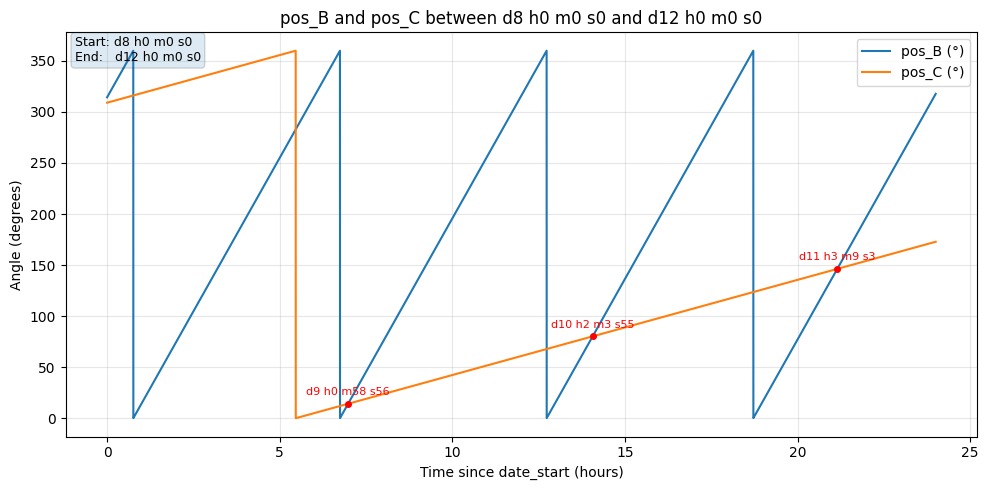

In [ ]:
date_start = {'y': 1,'d': 8, 'h': 0, 'm': 0, 's': 0} # start date for plotting
date_end = {'y': 1, 'd': 12, 'h': 0, 'm': 0, 's': 0} # end date for plotting
trajectory_time = 18000 # time between ejection and Kerbin periapsis (estimated (calculations to do later))

# Convert to UT (seconds) and create time grid
t0 = date_to_sec(**date_start)
t1 = date_to_sec(**date_end)
times = np.linspace(t0, t1, 10000)

def pos_B(t):
    # West Longitude = Negative (-68.5)
    # L_sid(t=0) = 90° [cite: 162]
    # Add Kerbin rotation
    return (-68.5 -13.8 + 90 + (360/kerbin.rot_period) * (t + trajectory_time)) % 360 #13.8 is in ° the arc we do between the perigee at 35000m and the landed site.

def pos_C(t):
    # 1.7 is in radians, convert to degrees: 1.7 * (180/pi)
    # Add Mun orbital motion
    mun_start_angle_deg = 1.7 * (180 / np.pi)
    mun_orbital_rate = 360 / (2 * np.pi * np.sqrt(mun.a**3 / kerbin.mu))
    return (180 + mun_start_angle_deg + mun_orbital_rate * t) % 360 # +180 because opposite to Mun

# For plotting, remove np.degrees():
# plt.plot((times - t0)/3600, vals_B, label='pos_B (°)')

vals_B = pos_B(times)
vals_C = pos_C(times)

# Plotting
plt.figure(figsize=(10,5))
plt.plot((times - t0)/3600, vals_B, label='pos_B (°)')
plt.plot((times - t0)/3600, vals_C, label='pos_C (°)')
plt.xlabel('Time since date_start (hours)')
plt.ylabel('Angle (degrees)')
plt.title(f'pos_B and pos_C between {ut_to_dh_str(t0)} and {ut_to_dh_str(t1)}')
plt.grid(alpha=0.3)
plt.legend()

# Optional: mark close intersections (same quadrant modulo 360)
diff = (vals_B - vals_C) % (360)
close_idx = np.where(np.abs(diff) < 0.1)[0]  # threshold 0.05°
for idx in close_idx:
    t = times[idx]
    plt.plot((t - t0) / 3600, (vals_B[idx]), 'ro', markersize=4)
    date_str = ut_to_dh_str(t)
    plt.annotate(date_str,
                 xy=((t - t0) / 3600, (vals_B[idx])),
                 xytext=(0, 6), textcoords='offset points',
                 fontsize=8, ha='center', color='red')

# Small text with start/end date
ax = plt.gca()
ax.text(0.01, 0.99,
        f"Start: {ut_to_dh_str(t0)}\nEnd:   {ut_to_dh_str(t1)}",
        transform=ax.transAxes, va='top', fontsize=9, bbox=dict(boxstyle='round', alpha=0.15))

plt.tight_layout()
plt.show()

### 4a. Trajectory Phasing and Correction

The intersection analysis (above) identifies a potential departure window around **Day 9, 0h 58m**. However, there is a phasing mismatch: at this exact time, the spacecraft is not correctly positioned at the Mun's hidden face to perform the burn.

The optimal position is reached **3,120 s later**. To synchronize the spacecraft with the window:
1. We perform a **phasing maneuver** to extend the current orbit's period to exactly **3,120 s**.
2. This requires raising the apoapsis to **78,816 m**, costing approximately **28 m/s** of $\Delta V$.
3. After one full orbit, the spacecraft will arrive at the burn point (periapsis) exactly when the return window opens.

In [ ]:
date_2 = {'y': 1, 'd': 9, 'h': 0, 'm': 59, 's': 0} # Estimated best time for the return maneuver (given the previous plot)
date_1 = {'y': 1, 'd': 9, 'h': 0, 'm': 7, 's': 0} # Second closest date to date_2 where the spaceship is at the right position for the return maneuver (hidden face of the Mun)

# The objective is to be again in the same position in the orbit as date_1 but at date_2

print(f"Date UT: {date_to_sec(**date_1)} s")
print(f"Date2 UT: {date_to_sec(**date_2)} s")

print(f"Difference: {date_to_sec(**date_2) - date_to_sec(**date_1)} s \nWe need to have a last orbit of 3120 s")

# T = 2 * pi * sqrt(a^3 / mu) => a = ((T / (2 * pi))^2 * mu)^(1/3)
a_last_orbit = ((((date_to_sec(**date_2) - date_to_sec(**date_1))/ (2 * np.pi))**2 * mun.mu))**(1/3)
h_apoapsis_last_orbit = 2 * a_last_orbit - mun.radius - r_pe # m
print(f"Apoapsis altitude for last orbit: {h_apoapsis_last_orbit:.0f} m")

# Delta V to elevate apoapsis from altitude_pe to h_apoapsis_last_orbit
r_apoapsis_last_orbit = mun.radius + h_apoapsis_last_orbit
v_periapsis_initial = np.sqrt(mun.mu/r_pe)
v_periapsis_final = np.sqrt(2*mun.mu/r_pe - 2* mun.mu/(r_apoapsis_last_orbit + r_pe))
dv_elevate_apoapsis = v_periapsis_final - v_periapsis_initial
print(f"Delta V to elevate apoapsis for last orbit: {dv_elevate_apoapsis:.0f} m/s")

Date UT: 173220 s
Date2 UT: 176340 s
Difference: 3120 s 
We need to have a last orbit of 3120 s
Apoapsis altitude for last orbit: 78816 m
Delta V to elevate apoapsis for last orbit: 28 m/s


![adjustment](images/adjustment_orbit2.png)

### 4b. Atmospheric Entry and Landing

The final return burn is executed at the periapsis of our phasing orbit. This places the spacecraft on a transfer trajectory with a **35 km vacuum perigee** inside Kerbin's atmosphere.

As calculated in our model, the atmospheric drag from 35 km downwards causes the lander to travel an additional **13.8°** of longitude before landing. This value was pre-calculated and subtracted from our target longitude in the `pos_B` function to ensure accurate touchdown.

![Kerbin_return](images/Kerbin_return.png)

## 5. Phase 5: Landing Precision Analysis

**Objective:** Validate the final landing accuracy relative to the target {4° N ; 68° 30' W}.

**Result:**
After the atmospheric descent, the lander touched down at **0° 10' 33" N ; 72° 11' 4" W**.

To quantify the precision of this landing, we calculate the great-circle distance between the actual landing site and the target coordinates using the **Haversine formula**. This formula provides the shortest distance between two points on a sphere, essential for navigation on planetary surfaces.

![kerbin_landed](images/kerbin_landed.png)

To compute the distance between two points on a sphere (Kerbin), we use the **Haversine** formula:

The Haversine formula computes the great-circle (orthodromic) distance — the shortest path on a sphere:

$$d = 2R \cdot \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

Where:
- φ1, φ2 = latitudes in radians
- λ1, λ2 = longitudes in radians  
- R = radius of Kerbin (600 km)

In [40]:
# Landed coordinates
landed_lat_dms = (0, 12, 33, 'N')
landed_lon_dms = (72, 11, 4, 'W')
landed_lat_dec = dms_to_dec(*landed_lat_dms)
landed_lon_dec = dms_to_dec(*landed_lon_dms)

print(f"Target: {target_lat_dec:.4f}°, {target_lon_dec:.4f}°")
print(f"Landed: {landed_lat_dec:.4f}°, {landed_lon_dec:.4f}°")

# Haversine formula for distance on a sphere
def haversine_distance(lat1, lon1, lat2, lon2, radius):
    """Calculate distance between two points on a sphere using Haversine formula."""
    lat1_rad, lat2_rad = np.radians(lat1), np.radians(lat2)
    lon1_rad, lon2_rad = np.radians(lon1), np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c

distance_landed_target = haversine_distance(target_lat_dec, target_lon_dec, 
                                             landed_lat_dec, landed_lon_dec, 
                                             kerbin.radius)

print(f"\nDistance between landed site and target: {distance_landed_target:.0f} m ({distance_landed_target/1000:.1f} km)")

Target: 4.0000°, -68.5000°
Landed: 0.2092°, -72.1844°

Distance between landed site and target: 55336 m (55.3 km)
